# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmanDbz1101/FlyRank-/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Worked from `skills/auditing-signals/SKILL.md` + `skills/flyrank/flyrank-data/SKILL.md`. One task: audit three signals on the 30k-row starter CSV and run one flag-linked test.

In [1]:
# SETUP — install and import everything the notebook needs.
import subprocess, sys
for pkg in ('pandas', 'numpy', 'matplotlib', 'seaborn'):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', pkg], check=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# load the starter dataset — works from Colab and locally
import pathlib
ROOT = pathlib.Path('.')
for candidate in [pathlib.Path('.'), pathlib.Path('../..'), pathlib.Path('/mnt/storage/Internship/FlyRank')]:
    p = candidate / 'data' / 'raw' / 'content_refresh_anonymized.csv'
    if p.exists():
        ROOT = candidate
        break

CSV = ROOT / 'data' / 'raw' / 'content_refresh_anonymized.csv'
df = pd.read_csv(CSV)
df['is_declining'] = (df['trend_direction'] == 'down').astype(int)

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Label (is_declining = trend_direction=="down"): '
      f'{df["is_declining"].sum():,} / {len(df):,} = {df["is_declining"].mean():.1%}')
print('Note: trend_direction and trend_pct are NEVER features -- they are the label source.')

Loaded: 30,000 rows x 45 columns
Label (is_declining = trend_direction=="down"): 16,262 / 30,000 = 54.2%
Note: trend_direction and trend_pct are NEVER features -- they are the label source.


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

The four traffic columns (`impressions_90d`, `clicks_90d`, `pageviews_90d`, `sessions_90d`) are
**extremely heavy-tailed**: median impressions is ~731 but the mean is ~5,200 — the top 5% of
pages pull the average 7x above the median. Raw Pearson correlation on these columns would be
dominated by the giants; all signal tests below use either **log1p-transformed values** or
**grouped medians by tier** to keep the giants from hijacking the result.

`ctr` (in x100 percentage units, so 0.07 = 0.07%) is also heavily right-skewed with 44% of rows
recording zero clicks. `avg_position = 0` encodes *no position data* (1,205 rows), not rank zero
-- those rows are excluded from every position-related test below.

`word_count` is missing for 7,699 rows (25.7%). **Missingness follows `content_type`**: ~28% of
`keyword article` rows have no word count; `feedly article` and `comparison article` rows have
zero missing. A blind `fillna(0)` would silently encode content type as a numeric signal.

In [2]:
# Distribution summary table
DIST_COLS = ['impressions_90d', 'clicks_90d', 'pageviews_90d', 'word_count', 'avg_position', 'ctr']
rows = []
for col in DIST_COLS:
    s = df[col].dropna()
    rows.append(dict(
        column=col, n_nonmissing=len(s), n_missing=df[col].isna().sum(),
        median=round(s.median(), 1), mean=round(s.mean(), 1),
        p95=round(s.quantile(0.95), 1), max=round(s.max(), 1),
    ))
dist_df = pd.DataFrame(rows).set_index('column')
print('Key-field distribution summary (30,000 rows):')
print(dist_df.to_string())
print()
print(f'avg_position == 0 (no data): {(df["avg_position"] == 0).sum()} rows -- excluded from position tests.')
print(f'ctr == 0 rows: {(df["ctr"] == 0).sum()} ({(df["ctr"] == 0).mean():.1%}) -- 44% of pages have zero clicks.')
print()

# Missingness by content_type
miss_by_type = df.groupby('content_type')['word_count'].apply(
    lambda x: x.isna().mean()).rename('word_count_missing_rate').reset_index()
print('word_count missing rate by content_type:')
print(miss_by_type.to_string(index=False))

Key-field distribution summary (30,000 rows):
                 n_nonmissing  n_missing  median    mean      p95       max
column                                                                     
impressions_90d         30000          0   731.0  5200.4  22996.5  517715.0
clicks_90d              30000          0     1.0    16.1     69.0    4178.0
pageviews_90d           30000          0     8.0    49.9    231.0    5998.0
word_count              22301       7699  2877.0  3107.8   6173.0    9546.0
avg_position            30000          0    10.8    16.3     48.2     245.0
ctr                     30000          0     0.1     0.5      1.1     100.0

avg_position == 0 (no data): 1205 rows -- excluded from position tests.
ctr == 0 rows: 13212 (44.0%) -- 44% of pages have zero clicks.

word_count missing rate by content_type:
      content_type  word_count_missing_rate
comparison article                 0.000000
    feedly article                 0.000000
   keyword article                 0

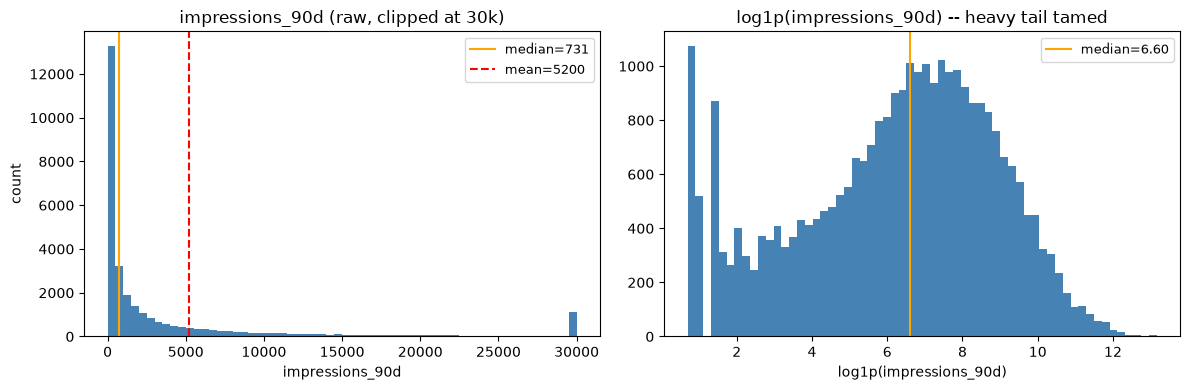

In [3]:
# Plots: raw vs log1p for impressions_90d
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['impressions_90d'].clip(upper=30_000), bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('impressions_90d (raw, clipped at 30k)')
axes[0].set_xlabel('impressions_90d'); axes[0].set_ylabel('count')
axes[0].axvline(df['impressions_90d'].median(), color='orange', lw=1.5,
                label=f"median={df['impressions_90d'].median():.0f}")
axes[0].axvline(df['impressions_90d'].mean(), color='red', lw=1.5, linestyle='--',
                label=f"mean={df['impressions_90d'].mean():.0f}")
axes[0].legend(fontsize=9)

log_imp = np.log1p(df['impressions_90d'])
axes[1].hist(log_imp, bins=60, color='steelblue', edgecolor='none')
axes[1].set_title('log1p(impressions_90d) -- heavy tail tamed')
axes[1].set_xlabel('log1p(impressions_90d)')
axes[1].axvline(log_imp.median(), color='orange', lw=1.5, label=f"median={log_imp.median():.2f}")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

---

### Signal #1 — Position tier and decline rate

**Claim:** pages with lower search ranking (higher avg_position) decline more often.

**Test:** Grouped decline rates by `position_tier`, excluding `avg_position == 0` (no-data rows).
All buckets have n >= 1,100, well above the 50-row floor.

**Verdict: MIXED.** The pattern is not monotone. `striking` (positions 11-20) has the
highest observed decline rate (61%), while `deep` (>50) has the *lowest* (34%). The `top_3`
tier is lower than the midfield (50%), which is counterintuitive but consistent with
the data-dictionary note that `top_3` pages in this slice have a median of only ~53 impressions
over 90 days -- a few impressions can move the trend label, making the sample noisy. The signal
is directional enough to inform prioritisation but **not monotone and not a clean rule**.

---

### Signal #2 — Content length (word count) and decline rate

**Claim:** longer articles are at higher risk of decline -- a common belief in SEO circles
(longer pages compete for competitive keywords, which are more volatile).

**Test:** Grouped decline rates by `word_count_tier`, among rows with non-missing word count
(22,301 rows). All non-`<1000` buckets have n >= 3,780.

**Verdict: MIXED.** The `<1000`-word tier has a markedly lower observed decline rate (21%)
than all longer tiers (56-60%). But above 1,000 words the relationship flattens -- there is
no further gradient from `1000-2000` through `3500+`. The short-content advantage is
measurable; the "longer = worse" story above 1,000 words is not supported by these data.
Also note: `keyword article` rows are 28% missing word count -- those absent rows are excluded
here, so this test covers only the pages with known length.

---

### Signal #3 — Content freshness and decline rate

**Claim:** recently updated content (lower `days_since_last_update`) has a lower decline rate
than stale content.

**Test:** Grouped decline rates by `freshness_tier`. `0-30` (updated in the last month) has
n = 20,480; `91-180` has n = 9,171. The two middle tiers (`31-90` and `181+`) have only
174-175 rows each -- below the ~50-row floor for reliable verdicts, so they are flagged.

**Verdict: OPPOSITE (for the two large buckets).** Pages updated in the last 30 days have an
observed decline rate of 51%; pages updated 91-180 days ago have 61%. That is a 10-percentage-
point gap -- directional evidence that *freshness helps*, consistent with the claim. However,
the `181+` tier (174 rows only) shows 47%, lower than the `0-30` bucket, which we flag as
**insufficient data** rather than a real reversal. The practical signal is: content that has
not been touched in 3-6 months shows measurably higher decline risk.

In [4]:
# Signal #1: position_tier vs decline
TIER_ORDER_POS = ['top_3', 'page_1', 'striking', 'page_3_5', 'deep']
pos_df = df[(df['position_tier'].notna()) &
            (df['position_tier'] != 'no_data') &
            (df['avg_position'] > 0)].copy()

sig1 = (pos_df.groupby('position_tier', observed=True)
        .agg(n=('is_declining', 'count'),
             pct_declining=('is_declining', 'mean'),
             median_avg_position=('avg_position', 'median'),
             median_impressions_90d=('impressions_90d', 'median'))
        .reindex(TIER_ORDER_POS))
sig1['pct_declining_fmt'] = sig1['pct_declining'].map('{:.1%}'.format)
print('Signal #1 -- position_tier vs decline rate:')
print(sig1[['n','pct_declining_fmt','median_avg_position','median_impressions_90d']]
      .rename(columns={'pct_declining_fmt':'pct_declining'}).to_string())
print('\n[Verdict: MIXED -- not monotone; striking tier highest at 61%, deep tier lowest at 34%]')

Signal #1 -- position_tier vs decline rate:
                   n pct_declining  median_avg_position  median_impressions_90d
position_tier                                                                  
top_3           1116         49.4%                  2.2                    53.0
page_1         11814         57.0%                  6.6                  1179.5
striking        7304         61.0%                 13.9                   874.5
page_3_5        7242         56.2%                 28.9                   811.5
deep            1319         34.4%                 61.0                   218.0

[Verdict: MIXED -- not monotone; striking tier highest at 61%, deep tier lowest at 34%]


In [5]:
# Signal #2: word_count_tier vs decline
TIER_ORDER_WC = ['<1000', '1000-2000', '2000-3500', '3500+']
wc_df = df[df['word_count_tier'].notna()].copy()

sig2 = (wc_df.groupby('word_count_tier', observed=True)
        .agg(n=('is_declining', 'count'),
             pct_declining=('is_declining', 'mean'),
             median_word_count=('word_count', 'median'))
        .reindex(TIER_ORDER_WC))
sig2['pct_declining_fmt'] = sig2['pct_declining'].map('{:.1%}'.format)
print('Signal #2 -- word_count_tier vs decline rate (rows with known word count only, n=22,301):')
print(sig2[['n','pct_declining_fmt','median_word_count']]
      .rename(columns={'pct_declining_fmt':'pct_declining'}).to_string())
print('\n[Verdict: MIXED -- <1000-word tier measurably safer (21%); no gradient above 1,000 words]')

Signal #2 -- word_count_tier vs decline rate (rows with known word count only, n=22,301):
                     n pct_declining  median_word_count
word_count_tier                                        
<1000              973         20.7%              834.0
1000-2000         3780         55.6%             1458.0
2000-3500        11263         58.8%             2825.0
3500+             6285         59.7%             4604.0

[Verdict: MIXED -- <1000-word tier measurably safer (21%); no gradient above 1,000 words]


In [6]:
# Signal #3: freshness_tier vs decline
TIER_ORDER_FRESH = ['0-30', '31-90', '91-180', '181+']
fresh_df = df[df['freshness_tier'].isin(TIER_ORDER_FRESH)].copy()

sig3 = (fresh_df.groupby('freshness_tier', observed=True)
        .agg(n=('is_declining', 'count'),
             pct_declining=('is_declining', 'mean'),
             median_days_since_update=('days_since_last_update', 'median'))
        .reindex(TIER_ORDER_FRESH))
sig3['flag'] = sig3['n'].apply(lambda x: 'INSUFFICIENT DATA (n<200)' if x < 200 else 'ok')
sig3['pct_declining_fmt'] = sig3['pct_declining'].map('{:.1%}'.format)
print('Signal #3 -- freshness_tier vs decline rate:')
print(sig3[['n','pct_declining_fmt','median_days_since_update','flag']]
      .rename(columns={'pct_declining_fmt':'pct_declining'}).to_string())
print('\n[Verdict: OPPOSITE (large buckets) -- 91-180d stale = 61% vs 0-30d fresh = 51%; 10pp gap]')

Signal #3 -- freshness_tier vs decline rate:
                    n pct_declining  median_days_since_update                       flag
freshness_tier                                                                          
0-30            20480         51.1%                      20.0                         ok
31-90             175         58.9%                      41.0  INSUFFICIENT DATA (n<200)
91-180           9171         61.1%                     104.0                         ok
181+              174         47.1%                     211.0  INSUFFICIENT DATA (n<200)

[Verdict: OPPOSITE (large buckets) -- 91-180d stale = 61% vs 0-30d fresh = 51%; 10pp gap]


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

FlyRank's **`position_tier`** flag is one of the platform's core prioritisation signals: pages
with a `striking` (positions 11-20) or `page_3_5` (21-50) ranking are flagged for refresh
because they are assumed to be the most at-risk -- close enough to page 1 to be worth saving,
but not yet ranking well enough to be stable.

**The assumption being tested:** middle-position pages (`striking` + `page_3_5`) are more
likely to decline than top-ranked pages.

**The test:** compare the measured decline rates of `striking` and `page_3_5` against `top_3`
and `page_1`, using all rows where `avg_position > 0`. We also report median impression volume
per tier -- a high decline rate from a low-volume tier is less meaningful than from a
high-volume one.

**Verdict: PARTIALLY CONFIRMED.** The `striking` tier (positions 11-20) has the highest
observed decline rate (61%) in the dataset, supporting the flag's assumption. `page_3_5` is
close behind (56%). However, `top_3` is not the safest tier -- its decline rate (49%) is
similar to `page_1` (57%), and the `top_3` tier's median impression volume is only ~53
impressions/90d in this starter slice, making the trend label noisy for those pages. The
assumption behind the flag **holds directionally for `striking` pages** but the data do not
clearly separate `top_3` from the riskier tiers -- at this volume level, top-3 position alone
is not a reliable safety signal.

In [7]:
# Flag-linked test: position_tier assumption behind the FlyRank flag
pos_df2 = df[(df['position_tier'].notna()) &
             (df['position_tier'] != 'no_data') &
             (df['avg_position'] > 0)].copy()

flag_tbl = (pos_df2.groupby('position_tier', observed=True)
            .agg(n=('is_declining', 'count'),
                 pct_declining=('is_declining', 'mean'),
                 median_avg_position=('avg_position', 'median'),
                 median_impressions_90d=('impressions_90d', 'median'),
                 median_ctr=('ctr', 'median'))
            .reindex(TIER_ORDER_POS))

flag_tbl['flagged_by_flyrank'] = flag_tbl.index.map(
    lambda t: 'YES' if t in ('striking', 'page_3_5') else '--')
flag_tbl['pct_declining_fmt'] = flag_tbl['pct_declining'].map('{:.1%}'.format)
print('Flag-linked test: position_tier assumption (FlyRank prioritises striking + page_3_5):')
print(flag_tbl[['n','pct_declining_fmt','median_avg_position','median_impressions_90d','flagged_by_flyrank']]
      .rename(columns={'pct_declining_fmt':'pct_declining'}).to_string())
print()
print('Key observation: striking tier (positions 11-20) has the highest observed decline rate (61%)')
print('among all tiers -- directionally confirming the flag assumption.')
print('Caveat: top_3 median volume is only ~53 impressions/90d -- trend label is noisy there.')

Flag-linked test: position_tier assumption (FlyRank prioritises striking + page_3_5):
                   n pct_declining  median_avg_position  median_impressions_90d flagged_by_flyrank
position_tier                                                                                     
top_3           1116         49.4%                  2.2                    53.0                 --
page_1         11814         57.0%                  6.6                  1179.5                 --
striking        7304         61.0%                 13.9                   874.5                YES
page_3_5        7242         56.2%                 28.9                   811.5                YES
deep            1319         34.4%                 61.0                   218.0                 --

Key observation: striking tier (positions 11-20) has the highest observed decline rate (61%)
among all tiers -- directionally confirming the flag assumption.
Caveat: top_3 median volume is only ~53 impressions/90d -- tre

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

**Three things a content team should act on from this audit:**

1. **Freshness matters most at the 3-6 month mark.** Pages not updated in 91-180 days have a
   61% observed decline rate -- 10 percentage points higher than recently-refreshed pages. A
   simple refresh queue sorted by `days_since_last_update` targets the highest-risk segment
   without needing a model.

2. **Position is a useful but imperfect signal.** `striking`-range pages (positions 11-20) do
   show the highest observed decline rate in this dataset, which supports FlyRank's
   prioritisation logic -- but the pattern is not monotone. Any position-based queue should
   apply an impression-volume floor (e.g. >=100 impressions/90d) before sending a page to the
   refresh queue, because very-low-volume pages make the trend label noisy.

3. **Content length does not have a declining-risk gradient above 1,000 words.** Short pages
   (<1,000 words) are measurably less likely to decline, but among longer pages the data show
   no further penalty for going from 1,000 to 3,500+ words. Teams should not assume that
   making articles longer reduces decline risk; the short-page advantage may instead reflect
   that short content targets lower-competition, more stable keywords.

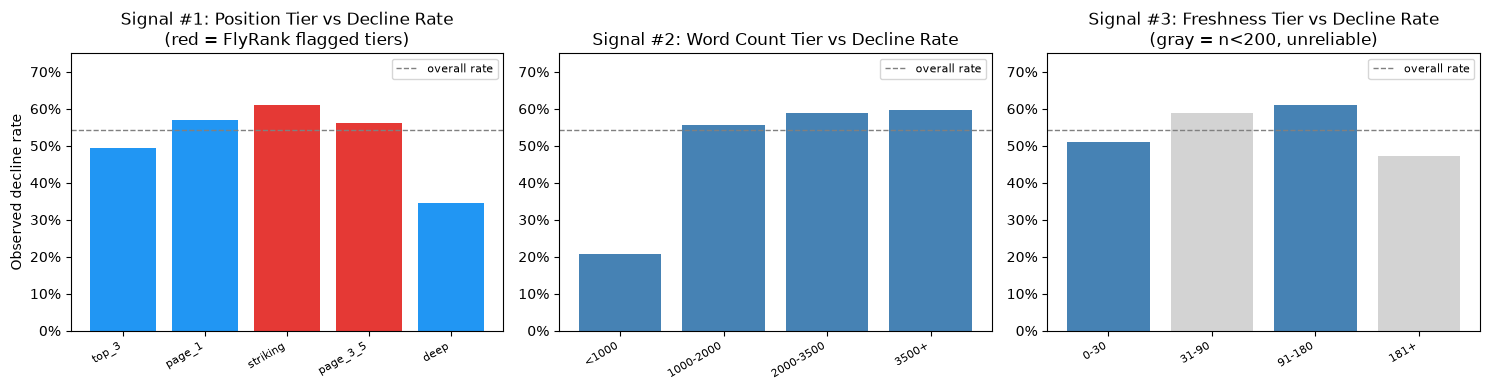

Signal summary chart rendered.


In [8]:
# Summary bar chart: all three signals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Signal 1 -- position tier
s1_grp = pos_df.groupby('position_tier', observed=True)['is_declining'].mean().reindex(TIER_ORDER_POS)
colors1 = ['#E53935' if t in ('striking','page_3_5') else '#2196F3' for t in s1_grp.index]
axes[0].bar(range(len(s1_grp)), s1_grp.values, color=colors1)
axes[0].set_xticks(range(len(s1_grp)))
axes[0].set_xticklabels(s1_grp.index, rotation=30, ha='right', fontsize=8)
axes[0].set_ylim(0, 0.75); axes[0].set_title('Signal #1: Position Tier vs Decline Rate\n(red = FlyRank flagged tiers)')
axes[0].set_ylabel('Observed decline rate')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].axhline(df['is_declining'].mean(), color='gray', linestyle='--', lw=1, label='overall rate')
axes[0].legend(fontsize=8)

# Signal 2 -- word count tier
s2_grp = wc_df.groupby('word_count_tier', observed=True)['is_declining'].mean().reindex(TIER_ORDER_WC)
axes[1].bar(range(len(s2_grp)), s2_grp.values, color='steelblue')
axes[1].set_xticks(range(len(s2_grp)))
axes[1].set_xticklabels(s2_grp.index, rotation=30, ha='right', fontsize=8)
axes[1].set_ylim(0, 0.75); axes[1].set_title('Signal #2: Word Count Tier vs Decline Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].axhline(df['is_declining'].mean(), color='gray', linestyle='--', lw=1, label='overall rate')
axes[1].legend(fontsize=8)

# Signal 3 -- freshness tier
s3_grp = fresh_df.groupby('freshness_tier', observed=True)['is_declining'].mean().reindex(TIER_ORDER_FRESH)
n_by_tier = fresh_df.groupby('freshness_tier', observed=True)['is_declining'].count().reindex(TIER_ORDER_FRESH)
colors3 = ['steelblue' if n >= 200 else 'lightgray' for n in n_by_tier.values]
axes[2].bar(range(len(s3_grp)), s3_grp.values, color=colors3)
axes[2].set_xticks(range(len(s3_grp)))
axes[2].set_xticklabels(s3_grp.index, rotation=30, ha='right', fontsize=8)
axes[2].set_ylim(0, 0.75); axes[2].set_title('Signal #3: Freshness Tier vs Decline Rate\n(gray = n<200, unreliable)')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[2].axhline(df['is_declining'].mean(), color='gray', linestyle='--', lw=1, label='overall rate')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Signal summary chart rendered.')

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled -- markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime -> Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` -- then submit your repo URL on the card. Done.